In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("intro2Keras.ipynb")

## Lecture Section

In this lecture, we will cover ideas and functions relating to the `keras` package.

We will cover:
* Neural Networks
    * What are they?
    * Activation Functions
    * Backpropogation
* Feed-forward Neural Networks (Continuous Output/Regression)
* Convolutional Neural Networks (Image Classification)

Install tensorflow then keras, please!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models

print("Keras version:", keras.__version__)

Keras version: 3.7.0


### What is a Neural Network?

A neural network is **not** a model of the brain - despite the name. It's a flexible mathematical function that learns to map inputs to outputs by composing many simpler functions.

Neural networks are primarily used for:
1. **Image classification** - e.g., is this a cat or a dog?
2. **Text generation** - e.g., predict the next word

Any other use case likely has a simpler model that can achieve similar metrics to a neural network with much more efficiency.

A neural network has three types of layers:

| Layer | Role |
|---|---|
| **Input** | Receives the raw features |
| **Hidden** | Learns intermediate representations |
| **Output** | Produces the final prediction |

Each connection between nodes has a **weight** (parameter). The output of each node is a **linear combination** of its inputs:

$$z = c_0 + c_1 x_1 + c_2 x_2 + \cdots$$

...passed through an **activation function**, which introduces non-linearity and defines how the signal moves from one layer to the next.

### The Three Things You Design

When building a neural network, you are making three types of decisions:

1. **Network architecture** - how many layers, how many nodes per layer, how they connect
2. **Activation functions** - what non-linear function is applied at each layer
3. **Optimization** - how the weights are updated during training (more on this shortly)

The output layer activation is a special case:
- For **numerical (regression) output**, there is **no activation function** on the output layer - we want raw numbers
- For **binary classification**, the output uses **sigmoid** (logit)
- For **multi-class classification**, the output uses **softmax**

### Activation Functions

Activation functions are applied after the linear combination at each node. Without them, stacking layers would still just produce a linear model. They introduce the **non-linearity** that makes deep networks powerful.

The three most common are:

#### ReLU (Rectified Linear Unit)
$$\text{ReLU}(x) = \max(0, x)$$
- If the output of the previous layer is positive, return the linear combination
- Otherwise, return 0
- Works for lots of problems, fast to compute
- Not smooth, can be difficult to optimize ("dying ReLU" problem)

#### Sigmoid (Logit)
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
- Same function as logistic regression - squashes output to (0, 1)
- Differentiable, easy to optimize
- Limited use cases - mainly for binary output layers

#### Softplus
$$\text{softplus}(x) = \log(1 + e^x)$$
- A smooth approximation of ReLU
- Differentiable, easy to optimize
- Limited use cases in practice

Let's visualize all three:

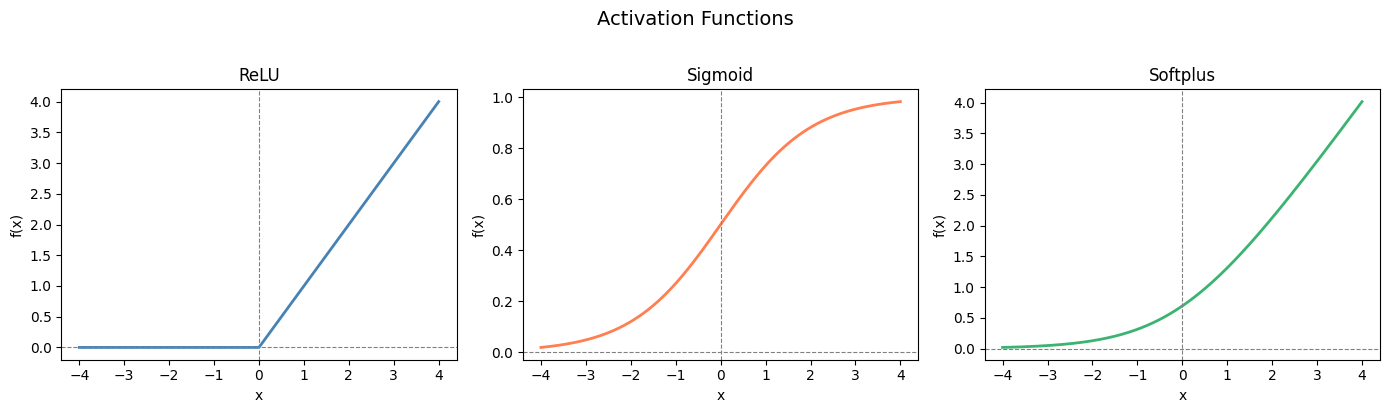

In [5]:
x = np.linspace(-4, 4, 300)

relu     = np.maximum(0, x)
sigmoid  = 1 / (1 + np.exp(-x))
softplus = np.log(1 + np.exp(x))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, y, name, color in zip(
    axes,
    [relu, sigmoid, softplus],
    ["ReLU", "Sigmoid", "Softplus"],
    ["steelblue", "coral", "mediumseagreen"]
):
    ax.plot(x, y, color=color, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')

plt.suptitle('Activation Functions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Notice that sigmoid looks like a log... because it is! If you use a sigmoid function with no hidden layers, you are performing logistic regression.

### Feedforward Neural Network - Regression Example

A **feedforward** network is the simplest kind - information flows in one direction: input → hidden layers → output. There are no loops.

Let's build one to predict housing prices from a small set of features. We'll use the California housing dataset from `keras`.

Since this is a **regression** task (predicting a continuous value), the output layer has:
- **1 node**
- **No activation function** (we want raw numerical output)

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features - neural networks train much better on standardized inputs
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Features:         {X_train.shape[1]}")
print(f"Feature names:    {housing.feature_names}")

Training samples: 16512
Features:         8
Feature names:    ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Now let's build the network. In `keras`, we use `keras.Sequential` to stack layers one after another.

- `layers.Dense(n, activation='relu')` - a fully connected layer with `n` nodes and ReLU activation
- The final `layers.Dense(1)` has **no activation** - this is the regression output

In [10]:
keras.utils.set_random_seed(42)

ffnn = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # no activation - numerical output
])

ffnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

The parameters are shown on the right. Notice that the parameters are the second column of the output shape * the output of the last layer + 1

For the first, for example, we have 64 * 8 (features) + 1 (intercept) = 576
For the second, we have 32 * 64 + 1 = 2,080
The rest follow the same pattern.

Before training, we need to **compile** the model. This is where we specify:
- **Loss function** - what we're minimizing (RMSE for regression → use `'mse'` and we'll take the square root)
- **Optimizer** - how we update weights (Adam is the standard choice - we won't discuss this here)

In [12]:
ffnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Now we train with `.fit()`. We pass in the training data, number of `epochs` (full passes through the data), and a `validation_split` so we can track performance on held-out data during training.

In [14]:
history = ffnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 601us/step - loss: 1.8655 - mae: 0.9789 - val_loss: 0.4672 - val_mae: 0.4948
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - loss: 0.4137 - mae: 0.4600 - val_loss: 0.4116 - val_mae: 0.4603
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - loss: 0.3724 - mae: 0.4340 - val_loss: 0.3967 - val_mae: 0.4494
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - loss: 0.3565 - mae: 0.4221 - val_loss: 0.3906 - val_mae: 0.4448
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - loss: 0.3468 - mae: 0.4147 - val_loss: 0.3900 - val_mae: 0.4409
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - loss: 0.3388 - mae: 0.4079 - val_loss: 0.3721 - val_mae: 0.4302
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 0.3296 - mae: 0.4010 - val_loss: 0.3483 - val_mae: 0.4156
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - loss: 0.3230 - mae: 0.3952 - val_loss: 0.3397 - val_mae: 0.4097
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 

Let's plot the training and validation loss over epochs to check that the model is learning and not overfitting.

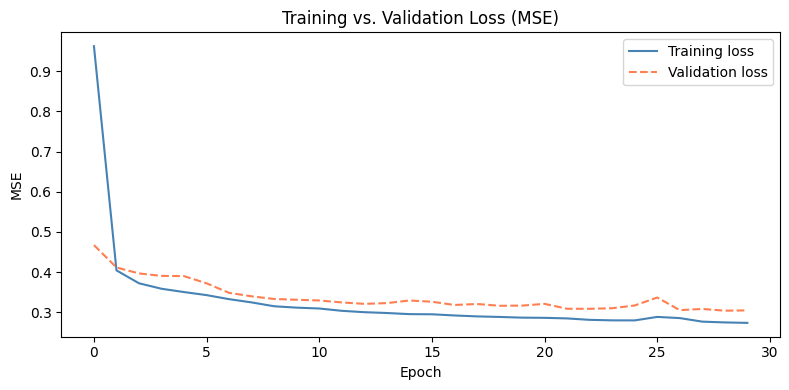

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation loss', color='coral', linestyle='--')
plt.title('Training vs. Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
test_mse, test_mae = ffnn.evaluate(X_test, y_test, verbose=0)
print(f"Test RMSE: {np.sqrt(test_mse):.4f}")
print(f"Test MAE:  {test_mae:.4f}")

Test RMSE: 0.5408
Test MAE:  0.3719


We seem to be learning!

### Optimization: Backpropagation

How does the network actually learn? The answer is **backpropagation** - an algorithm for efficiently computing how much each weight contributed to the loss, so we know which direction to adjust it.

The process repeats in a loop:

1. **Initialize weights** randomly
2. **Calculate loss** - e.g., RMSE between predictions and true values
3. **Optimize the last layer** - adjust its weights to reduce the loss; keep earlier layers fixed
4. **Repeat backwards** - move to the previous layer, optimize it, repeat until the first hidden layer
5. **Forward propagate** - run the updated network forward again on the next batch

This works because of the **chain rule** in calculus - the gradient of the loss with respect to an early layer's weights can be computed by chaining gradients through all the layers in between. This is why activation functions need to be differentiable (ReLU is only piecewise differentiable, which is one of its downsides).


### Convolutional Neural Networks (CNNs)

For image data, a standard feedforward network has a problem: images are grids of pixels, and the spatial arrangement matters. A 20×20 greyscale image has 400 pixels - but a flat vector of 400 numbers loses all information about which pixels are next to each other.

A **Convolutional Neural Network (CNN)** solves this by **convoluting** the image - applying small filters that slide across the image and detect local patterns (edges, textures, shapes). This transforms the pixel data into numerical features that the network can actually learn from, while preserving spatial structure.

A **Recurrent Neural Network (RNN)** does something analogous for sequential data - it uses a 'spatial' linear transformation to retain **order and context** (e.g., words in a sentence). We won't cover RNNs today.

#### CNN Architecture

A typical CNN has:
- **`Conv2D` layers** - apply filters to detect local features
- **`MaxPooling2D` layers** - downsample the feature maps (reduce size while important information)
- **`Flatten`** - convert the 2D feature maps into a 1D vector
- **`Dense` layers** - standard feedforward layers at the end
- **`Dropout` layers** - randomly drop nodes (a % chance for each node) between layers to prevent overfitting
- **Output layer** - with softmax for multi-class classification

We'll use the **MNIST** dataset - 70,000 greyscale images of handwritten digits (0–9), each 28×28 pixels.

In [20]:
# Load MNIST - already split into train/test
(X_train_img, y_train_img), (X_test_img, y_test_img) = keras.datasets.mnist.load_data()

print(f"Training images: {X_train_img.shape}  - (samples, height, width)")
print(f"Training labels: {y_train_img.shape}")
print(f"Pixel range before scaling: {X_train_img.min()} – {X_train_img.max()}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)  - (samples, height, width)
Training labels: (60000,)
Pixel range before scaling: 0 – 255


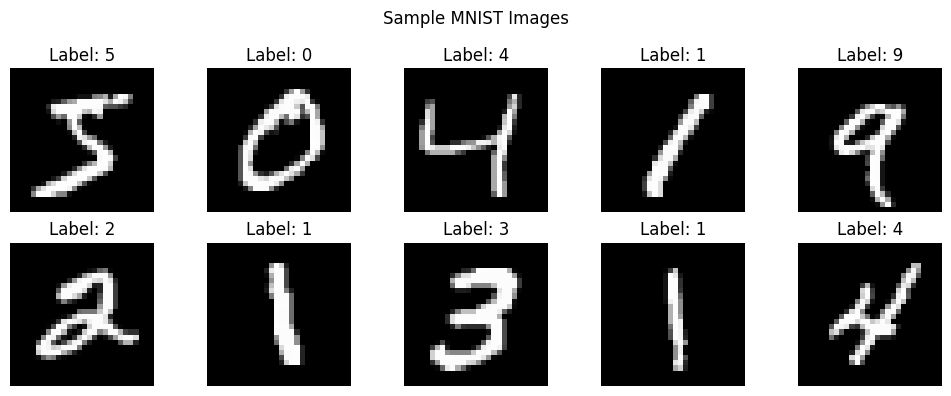

In [22]:
# Plot a sample of the digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_img[i], cmap='gray')
    ax.set_title(f"Label: {y_train_img[i]}")
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=12)
plt.tight_layout()
plt.show()

Before training, we need to:
1. **Reshape** - add a channel dimension. MNIST is greyscale so it's `(28, 28, 1)`. Color images would be `(height, width, 3)` for RGB.
2. **Normalize** - scale pixel values from [0, 255] to [0, 1]

In [24]:
# Reshape to (samples, height, width, channels) and normalize
X_train_img = X_train_img.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_img  = X_test_img.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels (10 classes: digits 0-9)
y_train_ohe = keras.utils.to_categorical(y_train_img, 10)
y_test_ohe  = keras.utils.to_categorical(y_test_img,  10)

print(f"Input shape: {X_train_img.shape}")
print(f"Label shape: {y_train_ohe.shape}  (one-hot encoded)")

Input shape: (60000, 28, 28, 1)
Label shape: (60000, 10)  (one-hot encoded)


Now let's build the CNN. The output layer uses **softmax** - one node per class, outputting a probability distribution over the 10 digit categories.

Earlier I said that there are three types o f layers - `input`, `output`, and `hidden`. This is still true - the other layers I introduced, such as `MaxPooling2D` - are not actual layers. However, nueral networks are built like sandwiches, and sandwiches have layers, so these extra functions are usually called `layers`, too.

Another note - usually you decrease the number of nodes as you work through a nerual network, but not for CNNs. Since you are compressing the image into smaller and smaller sections, you want to increase the nodes so that you do not lose too much information.

In [27]:
keras.utils.set_random_seed(42)

cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolutional block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes - softmax for multi-class output
])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # standard loss for multi-class classification
    metrics=['accuracy']
)

In [31]:
cnn_history = cnn.fit(
    X_train_img, y_train_ohe,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8659 - loss: 0.4916 - val_accuracy: 0.9842 - val_loss: 0.0588
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9810 - loss: 0.0620 - val_accuracy: 0.9875 - val_loss: 0.0427
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9871 - loss: 0.0407 - val_accuracy: 0.9898 - val_loss: 0.0367
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9908 - val_loss: 0.0347
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9934 - loss: 0.0226 - val_accuracy: 0.9907 - val_loss: 0.0350
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9952 - loss: 0.0174 - val_accuracy: 0.9892 - val_loss: 0.0358
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9962 - loss: 0.0142 - val_accuracy: 0.9892 - val_loss: 0.0394
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9966 - loss: 0.0113 - val_accu

In [32]:
test_loss, test_acc = cnn.evaluate(X_test_img, y_test_ohe, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.9895
Test loss:     0.0382


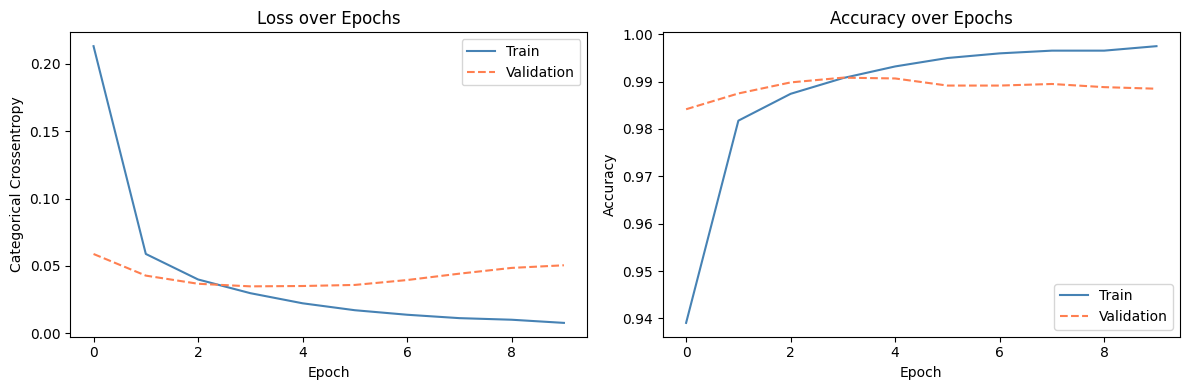

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history['loss'],     label='Train',      color='steelblue')
axes[0].plot(cnn_history.history['val_loss'], label='Validation', color='coral', linestyle='--')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()

axes[1].plot(cnn_history.history['accuracy'],     label='Train',      color='steelblue')
axes[1].plot(cnn_history.history['val_accuracy'], label='Validation', color='coral', linestyle='--')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

It looks like we start to overfit a little bit, but not too bad.

Let's visualize some predictions on the test set.

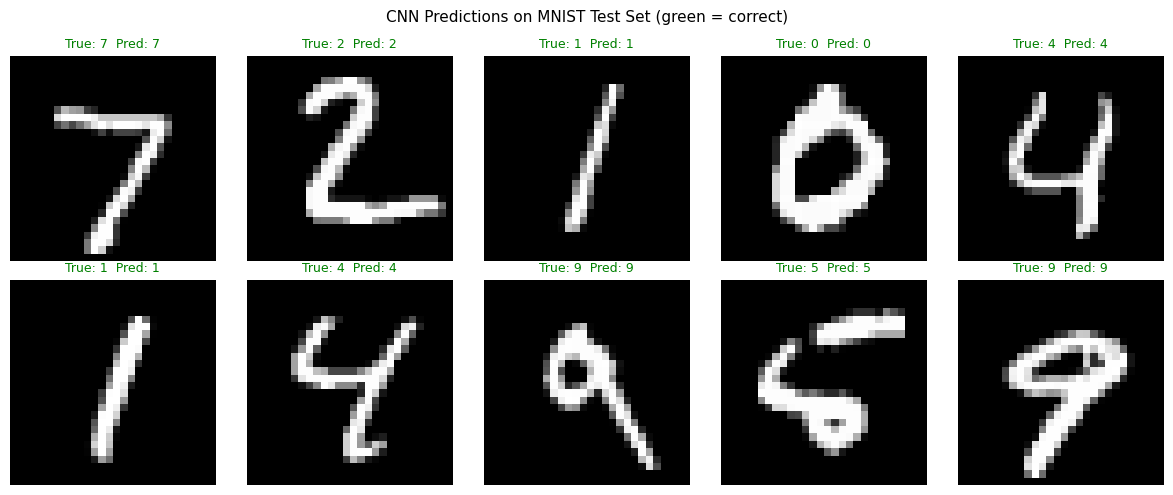

In [38]:
preds = np.argmax(cnn.predict(X_test_img[:10], verbose=0), axis=1)
true  = y_test_img[:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_img[i].reshape(28, 28), cmap='gray')
    color = 'green' if preds[i] == true[i] else 'red'
    ax.set_title(f"True: {true[i]}  Pred: {preds[i]}", color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CNN Predictions on MNIST Test Set (green = correct)', fontsize=11)
plt.tight_layout()
plt.show()

## Assignment Section

**Question 1.**

Complete the last CNN example, then do it again, below. This time, start with 128 nodes, then decrease to 64, then 32.

In [40]:
keras.utils.set_random_seed(42)

cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolutional block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes - softmax for multi-class output
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # standard loss for multi-class classification
    metrics=['accuracy']
)

cnn_history = cnn.fit(
    X_train_img, y_train_ohe,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

test_loss2, test_acc2 = cnn.evaluate(X_test_img, y_test_ohe, verbose=0)
print(f"Test accuracy: {test_acc2:.4f}")
print(f"Test loss:     {test_loss2:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8209 - loss: 0.5796 - val_accuracy: 0.9803 - val_loss: 0.0702
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9772 - loss: 0.0733 - val_accuracy: 0.9857 - val_loss: 0.0530
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9850 - loss: 0.0484 - val_accuracy: 0.9878 - val_loss: 0.0442
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.9890 - val_loss: 0.0384
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9903 - loss: 0.0297 - val_accuracy: 0.9888 - val_loss: 0.0388
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9930 - loss: 0.0237 - val_accuracy: 0.9895 - val_loss: 0.0382
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9945 - loss: 0.0199 - val_accuracy: 0.9890 - val_loss: 0.0419
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9954 - loss: 0.0165 - 

In [42]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.**
 For the data available here:
 https://github.com/JWarmenhoven/ISLR-python/blob/master/Notebooks/Data/Heart.csv

Use an LLM of your choice to:
1. Create a logistic regression model
2. Create a neural network model with `logit` and 0 hidden layers

For both, predict AHD from MaxHR+Age+Chol+RestBP.
Use the same train/test split for both.

Then, answer `True` or `False` with the variable `ans`:
    The accuracies of the two models are the same or similar.

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim

url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Heart.csv"
df = pd.read_csv(url)
df['AHD'] = df['AHD'].map({'Yes': 1, 'No': 0})


X = df[['MaxHR', 'Age', 'Chol', 'RestBP']].values
y = df['AHD'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"Logistic Regression Accuracy: {acc_log:.4f}")


class LogisticNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)


model = LogisticNN(input_dim=4)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


epochs = 10
for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    probs = model(X_test_t)
    preds = (probs >= 0.5).int().numpy().flatten()

acc_nn = accuracy_score(y_test, preds)

print(f"Neural Network (0 hidden layers) Accuracy: {acc_nn:.4f}")

# ---------------------------
# Final answer
# ---------------------------
ans = abs(acc_log - acc_nn) < 0.02  # tolerance
print("Are accuracies similar?", ans)


Logistic Regression Accuracy: 0.7541
Neural Network (0 hidden layers) Accuracy: 0.7541
Are accuracies similar? True


In [56]:
grader.check("q2")

q2 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [59]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!